# Cardiovascular Disease Prediction

Predicting the presence of cardiovascular disease using a dataset of 70,000 patient records. We compare five supervised ML classifiers and evaluate using accuracy, F1 score, and recall — prioritising recall since missing a sick patient is more costly than a false alarm.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Data Loading & Pre-processing

In [2]:
df = pd.read_csv('cardio_train (1).csv', delimiter=';')
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
df.head()

Dataset shape: (70000, 13)

First 5 rows:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [3]:
# Check missing values
print("Missing values:", df.isnull().sum().sum())

# Drop ID — not a predictive feature
df = df.drop('id', axis=1)

# Convert age from days to years
df['age'] = (df['age'] / 365.25).apply(np.floor).astype(int)

# Remove physiologically impossible blood pressure outliers
df = df[(df['ap_lo'] >= 50)  & (df['ap_lo'] <= 200)]
df = df[(df['ap_hi'] >= 80)  & (df['ap_hi'] <= 250)]
df = df[df['ap_hi'] > df['ap_lo']]

# Remove extreme height/weight outliers
df = df[(df['height'] >= 130) & (df['height'] <= 210)]
df = df[(df['weight'] >= 40)  & (df['weight'] <= 150)]

print(f"Shape after cleaning: {df.shape}")
print(f"Class balance (cardio):\n{df['cardio'].value_counts(normalize=True).round(3)}")

Missing values: 0
Shape after cleaning: (68467, 12)
Class balance (cardio):
cardio
0    0.505
1    0.495
Name: proportion, dtype: float64


## 2. Exploratory Data Analysis

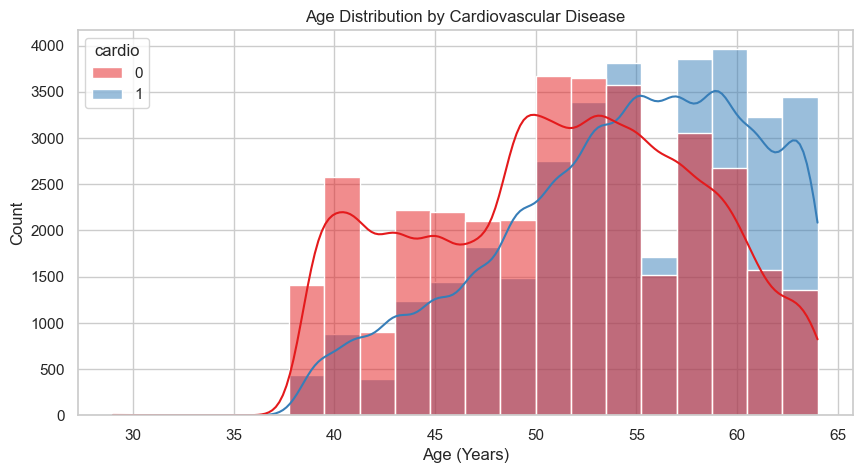

In [4]:
# Age distribution by target class
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='age', hue='cardio', kde=True, bins=20, palette='Set1')
plt.title('Age Distribution by Cardiovascular Disease')
plt.xlabel('Age (Years)')
plt.ylabel('Count')
plt.show()

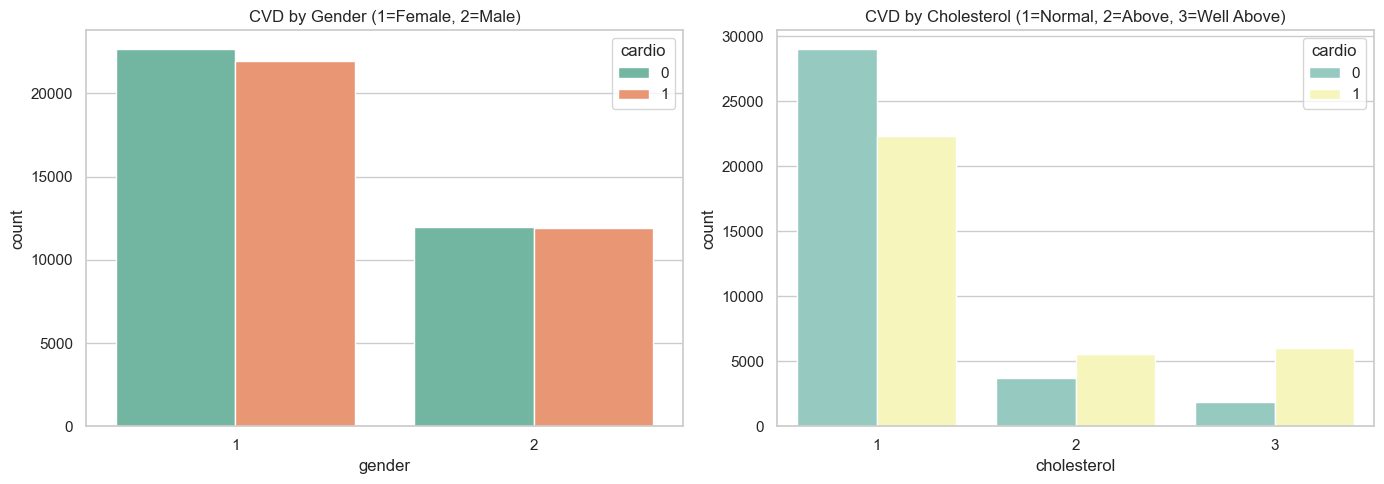

In [5]:
# Gender and Cholesterol breakdown
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='gender', hue='cardio', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('CVD by Gender (1=Female, 2=Male)')

sns.countplot(x='cholesterol', hue='cardio', data=df, palette='Set3', ax=axes[1])
axes[1].set_title('CVD by Cholesterol (1=Normal, 2=Above, 3=Well Above)')

plt.tight_layout()
plt.show()

## 3. Correlation Matrix

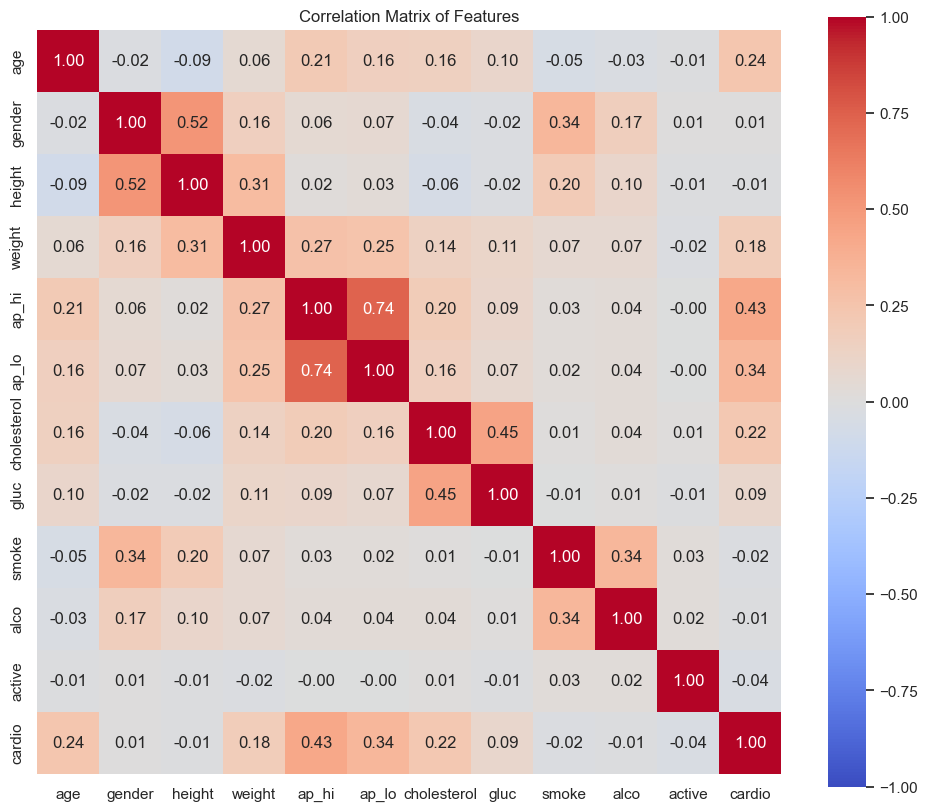

In [6]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix of Features')
plt.show()

## 4. Model Training & Evaluation

In [7]:
X = df.drop('cardio', axis=1)
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

Training set: (54773, 11), Test set: (13694, 11)


In [8]:
models = {
    "Logistic Regression":    LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree":          DecisionTreeClassifier(random_state=42),
    "Random Forest":          RandomForestClassifier(n_estimators=100, random_state=42),
    "K-Nearest Neighbors":    KNeighborsClassifier(),
    "Support Vector Machine": SVC(random_state=42)
}

# Models that require scaled input
needs_scaling = {"Support Vector Machine", "K-Nearest Neighbors", "Logistic Regression"}

results = {}
print(f"{'Model':<25} {'Accuracy':>10} {'Recall':>10} {'F1 Score':>10}")
print("-" * 60)

for name, model in models.items():
    Xtr = X_train_scaled if name in needs_scaling else X_train
    Xte = X_test_scaled  if name in needs_scaling else X_test

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)

    report = classification_report(y_test, y_pred, output_dict=True)
    acc    = accuracy_score(y_test, y_pred)
    recall = report['1']['recall']
    f1     = report['1']['f1-score']

    results[name] = {'model': model, 'accuracy': acc, 'recall': recall, 'f1': f1,
                     'needs_scaling': name in needs_scaling}
    print(f"{name:<25} {acc*100:>9.2f}% {recall*100:>9.2f}% {f1*100:>9.2f}%")

Model                       Accuracy     Recall   F1 Score
------------------------------------------------------------
Logistic Regression           72.71%     66.81%     70.76%
Decision Tree                 63.63%     61.98%     62.75%
Random Forest                 70.44%     69.84%     70.02%
K-Nearest Neighbors           69.72%     68.42%     69.08%
Support Vector Machine        73.27%     67.12%     71.28%


## 5. Model Comparison

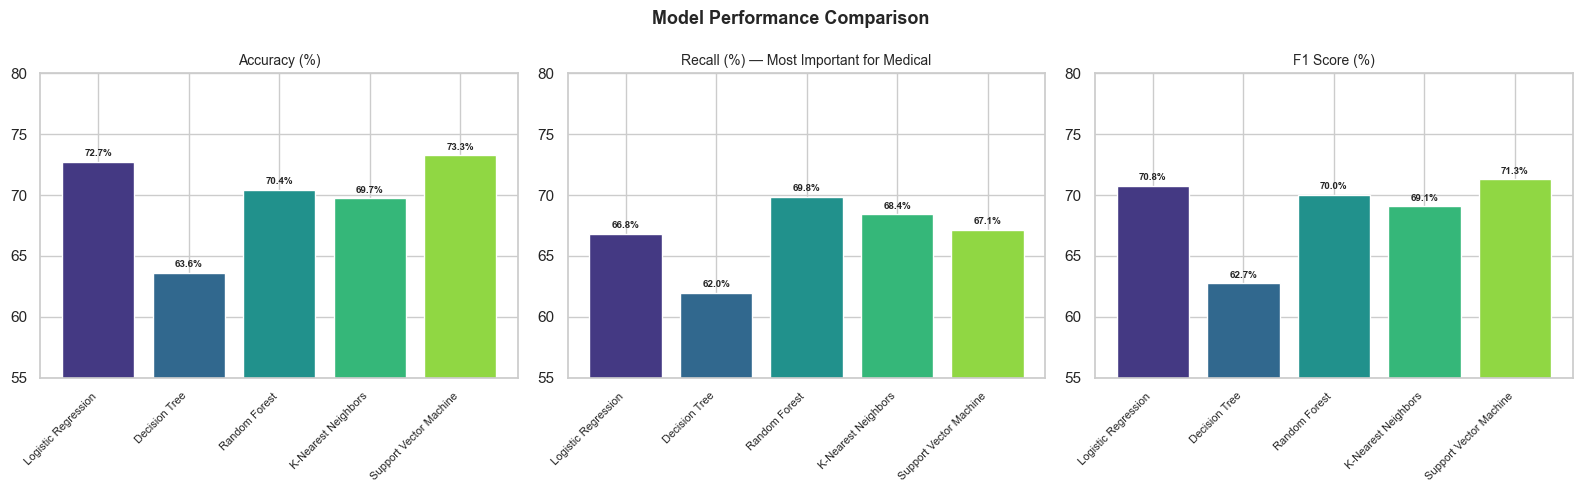

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
names = list(results.keys())
metrics = ['accuracy', 'recall', 'f1']
titles  = ['Accuracy (%)', 'Recall (%) — Most Important for Medical', 'F1 Score (%)']
colors  = [sns.color_palette("viridis", len(names))] * 3

for ax, metric, title in zip(axes, metrics, titles):
    values = [results[n][metric] * 100 for n in names]
    bars = ax.bar(names, values, color=sns.color_palette("viridis", len(names)))
    ax.set_title(title, fontsize=10)
    ax.set_ylim(55, 80)
    ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{bar.get_height():.1f}%", ha='center', va='bottom', fontsize=7, fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Best Model — Detailed Analysis

In [10]:
# Select best model by F1 score (balances precision and recall)
best_name = max(results, key=lambda n: results[n]['f1'])
best      = results[best_name]
print(f"Best model: {best_name}")
print(f"  Accuracy: {best['accuracy']*100:.2f}%")
print(f"  Recall:   {best['recall']*100:.2f}%")
print(f"  F1 Score: {best['f1']*100:.2f}%")

Best model: Support Vector Machine
  Accuracy: 73.27%
  Recall:   67.12%
  F1 Score: 71.28%


In [11]:
# Full classification report for best model
Xte = X_test_scaled if best['needs_scaling'] else X_test
y_pred_best = best['model'].predict(Xte)
print(f"\nClassification Report — {best_name}:")
print(classification_report(y_test, y_pred_best, target_names=['No Disease', 'Disease']))


Classification Report — Support Vector Machine:
              precision    recall  f1-score   support

  No Disease       0.71      0.79      0.75      6926
     Disease       0.76      0.67      0.71      6768

    accuracy                           0.73     13694
   macro avg       0.74      0.73      0.73     13694
weighted avg       0.74      0.73      0.73     13694



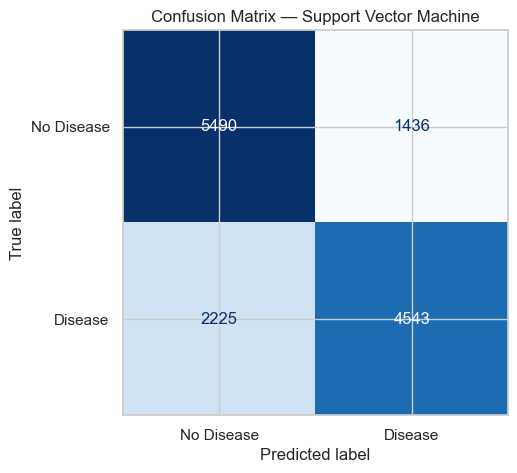

In [12]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title(f'Confusion Matrix — {best_name}')
plt.show()

## 7. Cross-Validation (Model Robustness Check)

In [14]:
# 5-fold cross-validation on the best model to verify results aren't a lucky split
Xfull = X_train_scaled if best['needs_scaling'] else X_train
cv_scores = cross_val_score(best['model'], Xfull, y_train, cv=5, scoring='f1')
print(f"5-Fold CV F1 Scores: {[f'{s:.3f}' for s in cv_scores]}")
print(f"Mean F1: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")
print("\nLow standard deviation = model is stable, not overfitting to one split.")

5-Fold CV F1 Scores: ['0.721', '0.719', '0.714', '0.708', '0.709']
Mean F1: 0.714 (+/- 0.005)

Low standard deviation = model is stable, not overfitting to one split.


## 8. Feature Importance (Random Forest)

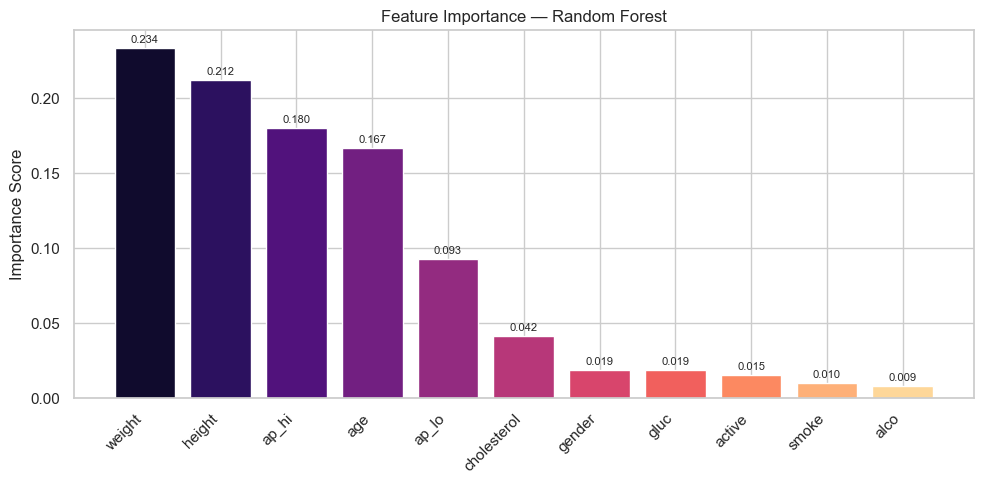


Top 3 most important features for CVD prediction:
  weight: 0.2337
  height: 0.2121
  ap_hi: 0.1801


In [15]:
# Feature importance is available from the Random Forest model
rf_model = results['Random Forest']['model']
feat_imp  = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(feat_imp.index, feat_imp.values, color=sns.color_palette("magma", len(feat_imp)))
plt.title('Feature Importance — Random Forest')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

print("\nTop 3 most important features for CVD prediction:")
for feat, imp in feat_imp.head(3).items():
    print(f"  {feat}: {imp:.4f}")

## 9. Save Best Model

In [16]:
# Save the best model and scaler for deployment/inference
joblib.dump(best['model'], 'cardio_best_model.pkl')
joblib.dump(scaler, 'cardio_scaler.pkl')
print(f"Model saved: cardio_best_model.pkl")
print(f"Scaler saved: cardio_scaler.pkl")
print(f"\nTo load and predict:")
print("  model  = joblib.load('cardio_best_model.pkl')")
print("  scaler = joblib.load('cardio_scaler.pkl')")
print("  pred   = model.predict(scaler.transform(new_data))")

Model saved: cardio_best_model.pkl
Scaler saved: cardio_scaler.pkl

To load and predict:
  model  = joblib.load('cardio_best_model.pkl')
  scaler = joblib.load('cardio_scaler.pkl')
  pred   = model.predict(scaler.transform(new_data))
